# Tutorial 02 — GPU Batching with TMol

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/master/docs/tutorial/02_gpu_batching.ipynb)

A `PoseStack` can hold several structures on one device. This tutorial builds repeated and mixed-size batches, scores them together, and measures basic GPU throughput.

## Learning objectives

- Build a batch with `PoseStackBuilder.from_poses()`.
- Score every batch member in one call and inspect its label.
- Measure latency, throughput, and memory after warmup.

## Before you begin

- **Prerequisites:** [01 — Working with TMol](01_working_with_tmol.ipynb), especially device selection and `PoseStack` construction.
- **Curriculum:** This is the second step in 01 → 02 → 03. Continue to [03 — Scoring and analysis](03_scoring_and_analysis.ipynb) before choosing the packing or minimization branch.
- **Related:** [GPU batching workflow](../workflows/gpu_batching.md) · [Benchmarking deep dive](../user_guide/benchmarking.md)

The small path runs on CPU. Representative timing and memory measurements require CUDA. A `PoseStack` uses one device; it is not distributed or multi-GPU execution.

## Setup

The benchmark fixes random seeds, discovers the checked-in 1UBQ fixture, and uses the same device for the pose, score function, and generated batches.

The controlled scaling benchmark uses only chain A residues 1–20. This small supported fragment keeps the CPU documentation path practical and makes repeated-pose batching cheap enough to demonstrate; it is not presented as a biological subsystem. Because slicing creates a new chain end, TMol assigns the appropriate terminal block type during import. Only this controlled timing fragment uses `no_optH=True`, leaving hydrogens at kinematically ideal positions so the benchmark setup remains lightweight.

The scientifically displayed heterogeneous example later uses full model-1 structures and the default `no_optH=False` preparation, which optimizes hydrogen positions and NHQ flips while rebuilding supported missing heavy atoms. Its table reports that preparation choice, deposited model counts, and deposited-versus-TMol-built atom counts.

In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "master/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab(
        [
            "tmol/tests/data/cif/1UBQ.cif",
            "tmol/tests/data/cif/1R21.cif",
            "tmol/tests/data/cif/1BL8.cif",
        ]
    )

In [2]:
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path
import platform
from time import perf_counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from biotite.structure import AtomArrayStack
from biotite.structure.io import load_structure

import tmol
from tmol.io import biotite_from_pose_stack, pose_stack_from_biotite
from tmol.pose import PoseStackBuilder
from tmol.score import beta2016_score_function

SEED = 20260807
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = (
    torch.device("cuda", torch.cuda.current_device())
    if torch.cuda.is_available()
    else torch.device("cpu")
)
repo_root = Path.cwd()
if not (repo_root / "tmol/tests/data/cif/1UBQ.cif").exists():
    repo_root = Path(tmol.__file__).resolve().parents[1]
cif_path = repo_root / "tmol/tests/data/cif/1UBQ.cif"

atom_array = load_structure(str(cif_path), model=1, include_bonds=True)
protein_slice = atom_array[(atom_array.chain_id == "A") & (atom_array.res_id <= 20)]
pose_diagnostics = StringIO()
try:
    with redirect_stdout(pose_diagnostics), redirect_stderr(pose_diagnostics):
        single_pose = pose_stack_from_biotite(protein_slice, device, no_optH=True)
except Exception:
    print(pose_diagnostics.getvalue())
    raise
score_function = beta2016_score_function(device)


def show_table(frame):
    """Use sortable tables in rendered docs, with a pandas fallback."""
    try:
        from itables import show
    except ImportError:
        return display(frame)
    return show(frame)


print(f"benchmark device: {device}; input: {cif_path.name}")

benchmark device: cpu; input: 1UBQ.cif


## Record benchmark metadata first

Latency numbers are not portable without the PyTorch/TMol versions, operating system, CUDA runtime, and GPU identity. Record these before timing. Peak memory below is CUDA allocator memory, not total process or driver memory.

In [3]:
metadata = {
    "platform": platform.platform(),
    "python": platform.python_version(),
    "tmol": tmol.__version__,
    "torch": torch.__version__,
    "device": str(device),
    "cuda_runtime": torch.version.cuda,
}
if device.type == "cuda":
    props = torch.cuda.get_device_properties(device)
    metadata.update(
        {
            "gpu_name": props.name,
            "compute_capability": f"{props.major}.{props.minor}",
            "gpu_memory_GiB": props.total_memory / 2**30,
        }
    )
metadata_frame = pd.DataFrame.from_dict(metadata, orient="index", columns=["value"])
show_table(metadata_frame.reset_index(names="property"))

## Build batches explicitly

`PoseStackBuilder.from_poses` concatenates compatible pose stacks and repacks their tensors on the requested device. Repeating the same pose is useful for a controlled throughput demonstration; real workloads normally batch distinct but chemistry-compatible structures.

In [4]:
preview_batch = PoseStackBuilder.from_poses([single_pose] * 4, device)
print("single coords:", tuple(single_pose.coords.shape))
print("batch coords: ", tuple(preview_batch.coords.shape))
print("batch poses:  ", preview_batch.n_poses)

single coords: (1, 327, 3)
batch coords:  (4, 327, 3)
batch poses:   4


## Score a heterogeneous CIF batch

Repeating one pose isolates batching overhead, but production batches usually contain different structures. Here model 1 from each of three checked-in CIF entries is converted independently with optimized hydrogens (`no_optH=False`), combined into one `PoseStack`, scored in one call, and exposed through a structure selector. The 1R21 entry is an NMR ensemble, so its deposited model count is reported and its displayed structure is labeled explicitly as model 1 rather than as the complete ensemble. The batch pads its block and atom dimensions to the largest member, so every pose occupies the batch's fixed rectangular layout; grouping similarly sized structures reduces wasted storage and work.

The preparation table gives deposited and TMol-built totals. Their difference can be reported, but it is not an exact atom-provenance statement: conversion may exclude unsupported material, select chemical variants, and build supported missing atoms, while the public API does not identify every output atom as retained or constructed. In this fixture set, 1BL8 contains a deposited `K` ion that TMol does not recognize and excludes; the table names that known removal explicitly.

This is the core GPU workflow: one tensor operation returns one weighted total per structure, while the label table and switcher preserve every input's identity. Each structure is also scored by its own independently rendered module, and the notebook asserts agreement with the corresponding batched total within floating-point tolerance. These beta2016 totals are score-function units, not physical energies. Because the proteins are unrelated and differ in size and composition, their absolute totals are **not scientifically comparable**; this table demonstrates batch indexing and labeling, not a ranking.

In [5]:
structure_specs = [
    ("1UBQ — ubiquitin", "1UBQ.cif"),
    ("1R21 — model 1", "1R21.cif"),
    ("1BL8", "1BL8.cif"),
]
individual_poses = {}
preparation_records = {}
for label, filename in structure_specs:
    structure_file = load_structure(
        str(repo_root / "tmol" / "tests" / "data" / "cif" / filename),
        include_bonds=True,
    )
    if isinstance(structure_file, AtomArrayStack):
        deposited_model_count = structure_file.stack_depth()
        structure = structure_file[0]
    else:
        deposited_model_count = 1
        structure = structure_file

    pose_diagnostics = StringIO()
    try:
        with redirect_stdout(pose_diagnostics), redirect_stderr(pose_diagnostics):
            pose = pose_stack_from_biotite(structure, device, no_optH=False)
    except Exception:
        print(pose_diagnostics.getvalue())
        raise
    individual_poses[label] = pose
    tmol_built_structure = biotite_from_pose_stack(pose)
    preparation_records[label] = {
        "deposited_models": deposited_model_count,
        "selected_model": 1,
        "deposited_atoms": structure.array_length(),
        "TMol_built_atoms": tmol_built_structure.array_length(),
        "net_atom_count_change": (
            tmol_built_structure.array_length() - structure.array_length()
        ),
        "count_interpretation": (
            "net filtering plus selected/built chemistry; no per-atom provenance"
        ),
        "preparation": "no_optH=False (OptH optimized)",
        "known_excluded_material": "K ion" if filename == "1BL8.cif" else "",
    }

heterogeneous_batch = PoseStackBuilder.from_poses(
    list(individual_poses.values()), device
)
heterogeneous_scorer = score_function.render_whole_pose_scoring_module(
    heterogeneous_batch
)
with warnings.catch_warnings(), torch.no_grad():
    warnings.filterwarnings("ignore", message=r"Sparse index lookup.*")
    heterogeneous_scores = heterogeneous_scorer(
        heterogeneous_batch.coords
    ).detach().cpu().numpy()

independent_scores = []
with warnings.catch_warnings(), torch.no_grad():
    warnings.filterwarnings("ignore", message=r"Sparse index lookup.*")
    for pose in individual_poses.values():
        independent_scorer = score_function.render_whole_pose_scoring_module(pose)
        independent_score = independent_scorer(pose.coords).detach().cpu().numpy()
        independent_scores.append(float(independent_score.reshape(-1)[0]))
independent_scores = np.asarray(independent_scores)
np.testing.assert_allclose(
    heterogeneous_scores,
    independent_scores,
    rtol=1e-5,
    atol=1e-3,
)

batch_rows = []
for pose_index, (label, pose) in enumerate(individual_poses.items()):
    preparation = preparation_records[label]
    batch_rows.append(
        {
            "pose_index": pose_index,
            "structure": label,
            **preparation,
            "blocks": pose.max_n_blocks,
            "pose_atoms": pose.max_n_pose_atoms,
            "batched_weighted_score": float(heterogeneous_scores[pose_index]),
            "independent_weighted_score": float(independent_scores[pose_index]),
            "absolute_score_difference": float(
                abs(heterogeneous_scores[pose_index] - independent_scores[pose_index])
            ),
        }
    )
batch_frame = pd.DataFrame(batch_rows)
show_table(batch_frame)
print(
    "maximum batched-vs-independent absolute difference:",
    f"{batch_frame['absolute_score_difference'].max():.6g}",
)
display(
    tmol.switchable_view(
        individual_poses,
        notes={
            row["structure"]: (
                f"batch index {row['pose_index']}; model {row['selected_model']} of "
                f"{row['deposited_models']}; {row['blocks']} blocks; "
                f"score {row['batched_weighted_score']:.3f}; optimized H"
            )
            for row in batch_rows
        },
    )
)

maximum batched-vs-independent absolute difference: 0.000244141


## Execute heterogeneous versus size-bucketed scoring

The three prepared structures differ substantially in block and atom count. To make padding measurable rather than hypothetical, each structure is repeated twice. The same six poses are then scored in two layouts:

- one heterogeneous six-pose batch padded to the largest member; and
- three homogeneous two-pose buckets, one per structure size.

Scorers are rendered before timing, scores are verified in the same logical order, and the table separates rectangular padding, throughput, and the incremental CUDA allocator peak above each post-warmup baseline. Bucketing reduces padded tensor slots but requires more kernel launches; neither layout is universally faster.


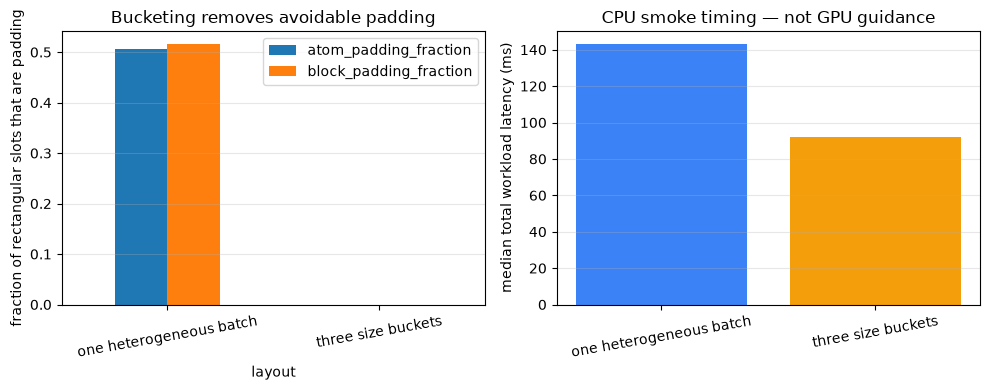

In [6]:
workload_labels = [label for label in individual_poses for _ in range(2)]
workload_poses = [individual_poses[label] for label in workload_labels]
layout_groups = {
    "one heterogeneous batch": [workload_poses],
    "three size buckets": [
        [individual_poses[label], individual_poses[label]] for label in individual_poses
    ],
}


def build_layout(groups):
    """Build all batches and rendered scorers for one workload layout."""
    batches = [PoseStackBuilder.from_poses(group, device) for group in groups]
    scorers = [
        score_function.render_whole_pose_scoring_module(batch) for batch in batches
    ]
    return batches, scorers


def run_layout(batches, scorers):
    """Score each pre-rendered group and concatenate in workload order."""
    return torch.cat(
        [scorer(batch.coords) for batch, scorer in zip(batches, scorers, strict=True)]
    )


def time_layout(batches, scorers, repeats, warmup):
    """Measure aggregate latency for all calls in one workload layout."""
    with torch.no_grad():
        for _ in range(warmup):
            run_layout(batches, scorers)
        if device.type == "cuda":
            torch.cuda.synchronize(device)
            baseline_bytes = torch.cuda.memory_allocated(device)
            torch.cuda.reset_peak_memory_stats(device)
        else:
            baseline_bytes = np.nan
        elapsed = []
        for _ in range(repeats):
            if device.type == "cuda":
                torch.cuda.synchronize(device)
            start_time = perf_counter()
            run_layout(batches, scorers)
            if device.type == "cuda":
                torch.cuda.synchronize(device)
            elapsed.append(perf_counter() - start_time)
    if device.type == "cuda":
        incremental_peak_bytes = max(
            0, torch.cuda.max_memory_allocated(device) - baseline_bytes
        )
    else:
        incremental_peak_bytes = np.nan
    return 1e3 * np.asarray(elapsed), incremental_peak_bytes


built_layouts = {label: build_layout(groups) for label, groups in layout_groups.items()}
with torch.no_grad():
    layout_scores = {
        label: run_layout(*layout).detach().cpu()
        for label, layout in built_layouts.items()
    }
torch.testing.assert_close(
    layout_scores["one heterogeneous batch"],
    layout_scores["three size buckets"],
    rtol=1e-5,
    atol=1e-3,
)

useful_atoms = sum(int(pose.real_atoms.sum().item()) for pose in workload_poses)
useful_blocks = sum(
    int((pose.block_type_ind64 >= 0).sum().item()) for pose in workload_poses
)
layout_rows = []
layout_repeats = 7 if device.type == "cuda" else 2
layout_warmup = 3 if device.type == "cuda" else 1
for label, (batches, scorers) in built_layouts.items():
    elapsed_ms, incremental_peak_bytes = time_layout(
        batches,
        scorers,
        repeats=layout_repeats,
        warmup=layout_warmup,
    )
    atom_slots = sum(batch.n_poses * batch.max_n_pose_atoms for batch in batches)
    block_slots = sum(batch.n_poses * batch.max_n_blocks for batch in batches)
    layout_rows.append(
        {
            "layout": label,
            "score_calls_per_workload": len(batches),
            "poses": len(workload_poses),
            "useful_atom_slots": useful_atoms,
            "rectangular_atom_slots": atom_slots,
            "atom_padding_fraction": 1.0 - useful_atoms / atom_slots,
            "useful_block_slots": useful_blocks,
            "rectangular_block_slots": block_slots,
            "block_padding_fraction": 1.0 - useful_blocks / block_slots,
            "median_total_latency_ms": float(np.median(elapsed_ms)),
            "throughput_poses_s": float(
                1e3 * len(workload_poses) / np.median(elapsed_ms)
            ),
            "latency_IQR_ms": float(
                np.percentile(elapsed_ms, 75) - np.percentile(elapsed_ms, 25)
            ),
            "incremental_peak_cuda_MiB": incremental_peak_bytes / 2**20,
            "measurement": (
                "CUDA workload timing"
                if device.type == "cuda"
                else "CPU smoke timing; not GPU guidance"
            ),
        }
    )
layout_frame = pd.DataFrame(layout_rows)
show_table(layout_frame)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
padding_plot = layout_frame.set_index("layout")[
    ["atom_padding_fraction", "block_padding_fraction"]
]
padding_plot.plot.bar(ax=axes[0], rot=10)
axes[0].set(
    ylabel="fraction of rectangular slots that are padding",
    title="Bucketing removes avoidable padding",
)
axes[1].bar(
    layout_frame["layout"],
    layout_frame["median_total_latency_ms"],
    color=["#3b82f6", "#f59e0b"],
)
axes[1].set(
    ylabel="median total workload latency (ms)",
    title=(
        "Measured CUDA workload"
        if device.type == "cuda"
        else "CPU smoke timing — not GPU guidance"
    ),
)
axes[1].tick_params(axis="x", rotation=10)
for axis in axes:
    axis.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

**Expected observations.** Size bucketing removes padding because each two-pose group has one shape, while the heterogeneous layout makes every member occupy the largest rectangular dimensions. The latency result may favor either layout: one mixed call has more padded work, whereas three buckets incur three launches. The incremental CUDA peak measures temporary PyTorch allocation above each post-warmup baseline, not total process or driver memory. Use measured throughput and memory on the target workload, not padding fraction alone, to choose bucket boundaries. The CPU row is an execution smoke check and must not be presented as GPU scaling evidence.


## Benchmark methodology

`render_whole_pose_scoring_module(batch)` creates a scorer for that batch's fixed block, atom, and connectivity layout. Reuse it while only coordinates change within the same layout. Re-render when batch size, membership, padding dimensions, or chemical layout changes; `benchmark_scoring()` therefore renders once for each batch size and excludes that construction from the timed region.

CUDA launches are asynchronous. A valid wall-clock measurement therefore:

1. renders the scorer before timing and records the post-construction allocator baseline;
2. resets peak-memory statistics relative to that live baseline;
3. runs untimed warmup calls so lazy compilation and caches are not charged to steady-state latency;
4. synchronizes before starting and after finishing each timed call; and
5. reports multiple repeats rather than one launch.

The table's `latency_ms` is median **total latency for one batch call** and is accompanied by Q1, Q3, IQR, minimum, and maximum. `latency_per_pose_ms` divides the median total by batch size and is an amortized throughput metric, not the time at which one pose's result becomes independently available. Plot error bars span Q1–Q3. CUDA memory reports the post-construction live allocation, total observed peak, and the incremental peak above that baseline. The CPU path uses the same timing function without CUDA synchronization and deliberately tiny sizes.

In [7]:
def benchmark_scoring(batch_size, repeats=5, warmup=2):
    batch = PoseStackBuilder.from_poses([single_pose] * batch_size, device)
    scorer = score_function.render_whole_pose_scoring_module(batch)

    if device.type == "cuda":
        torch.cuda.synchronize(device)
        post_construction_bytes = torch.cuda.memory_allocated(device)
        torch.cuda.reset_peak_memory_stats(device)
    else:
        post_construction_bytes = np.nan

    with torch.no_grad():
        for _ in range(warmup):
            scorer(batch.coords)
        if device.type == "cuda":
            torch.cuda.synchronize(device)

        elapsed = []
        for _ in range(repeats):
            if device.type == "cuda":
                torch.cuda.synchronize(device)
            start = perf_counter()
            scorer(batch.coords)
            if device.type == "cuda":
                torch.cuda.synchronize(device)
            elapsed.append(perf_counter() - start)

    elapsed_ms = 1e3 * np.asarray(elapsed)
    latency_q1_ms, latency_q3_ms = np.percentile(elapsed_ms, [25, 75])
    latency_ms = float(np.median(elapsed_ms))
    if device.type == "cuda":
        peak_bytes = torch.cuda.max_memory_allocated(device)
        incremental_peak_bytes = max(0, peak_bytes - post_construction_bytes)
    else:
        peak_bytes = np.nan
        incremental_peak_bytes = np.nan
    return {
        "batch_size": batch_size,
        "latency_min_ms": float(elapsed_ms.min()),
        "latency_q1_ms": float(latency_q1_ms),
        "latency_ms": latency_ms,
        "latency_q3_ms": float(latency_q3_ms),
        "latency_max_ms": float(elapsed_ms.max()),
        "latency_iqr_ms": float(latency_q3_ms - latency_q1_ms),
        "throughput_poses_s": 1e3 * batch_size / latency_ms,
        "post_construction_cuda_MiB": post_construction_bytes / 2**20,
        "peak_cuda_MiB": peak_bytes / 2**20,
        "incremental_peak_cuda_MiB": incremental_peak_bytes / 2**20,
        "repeats": repeats,
    }


batch_sizes = [1, 4, 16, 64] if device.type == "cuda" else [1, 2, 4]
repeats = 5 if device.type == "cuda" else 2
benchmark_frame = pd.DataFrame(
    [benchmark_scoring(size, repeats=repeats) for size in batch_sizes]
)
benchmark_frame["latency_per_pose_ms"] = (
    benchmark_frame["latency_ms"] / benchmark_frame["batch_size"]
)
benchmark_frame["latency_per_pose_q1_ms"] = (
    benchmark_frame["latency_q1_ms"] / benchmark_frame["batch_size"]
)
benchmark_frame["latency_per_pose_q3_ms"] = (
    benchmark_frame["latency_q3_ms"] / benchmark_frame["batch_size"]
)
benchmark_frame["throughput_q1_poses_s"] = (
    1e3 * benchmark_frame["batch_size"] / benchmark_frame["latency_q3_ms"]
)
benchmark_frame["throughput_q3_poses_s"] = (
    1e3 * benchmark_frame["batch_size"] / benchmark_frame["latency_q1_ms"]
)
benchmark_frame["throughput_vs_batch_1"] = (
    benchmark_frame["throughput_poses_s"]
    / benchmark_frame.loc[0, "throughput_poses_s"]
)
benchmark_frame.insert(
    0, "measurement", "CUDA throughput" if device.type == "cuda" else "CPU smoke check"
)
show_table(benchmark_frame)

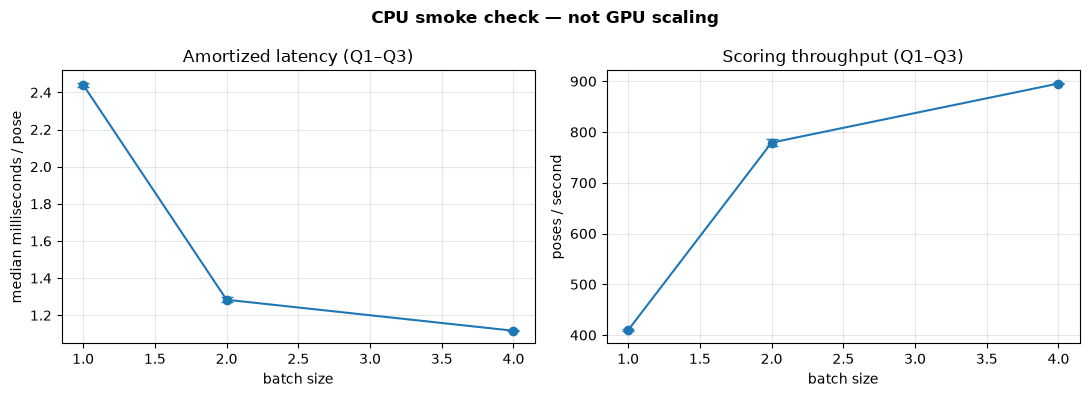

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
latency_yerr = np.vstack(
    [
        benchmark_frame["latency_per_pose_ms"]
        - benchmark_frame["latency_per_pose_q1_ms"],
        benchmark_frame["latency_per_pose_q3_ms"]
        - benchmark_frame["latency_per_pose_ms"],
    ]
)
axes[0].errorbar(
    benchmark_frame["batch_size"],
    benchmark_frame["latency_per_pose_ms"],
    yerr=latency_yerr,
    marker="o",
    capsize=4,
)
axes[0].set(
    xlabel="batch size",
    ylabel="median milliseconds / pose",
    title="Amortized latency (Q1–Q3)",
)
throughput_yerr = np.vstack(
    [
        benchmark_frame["throughput_poses_s"]
        - benchmark_frame["throughput_q1_poses_s"],
        benchmark_frame["throughput_q3_poses_s"]
        - benchmark_frame["throughput_poses_s"],
    ]
)
axes[1].errorbar(
    benchmark_frame["batch_size"],
    benchmark_frame["throughput_poses_s"],
    yerr=throughput_yerr,
    marker="o",
    capsize=4,
)
axes[1].set(
    xlabel="batch size",
    ylabel="poses / second",
    title="Scoring throughput (Q1–Q3)",
)
for axis in axes:
    axis.grid(alpha=0.3)
fig.suptitle(
    "Measured CUDA batching" if device.type == "cuda" else "CPU smoke check — not GPU scaling",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

**Expected observations.** Over the range where one pose under-fills a GPU, total batch-call latency generally grows more slowly than batch size. That is why the separate amortized metric—total milliseconds divided by poses—falls and throughput rises until compute or memory bandwidth saturates. The total latency does not become a per-pose latency, and batching is not superlinear algorithmic scaling: scoring work still grows with the number of poses.

The published documentation executes this notebook on a CI GPU after warmup, so its tables and plots are real CUDA measurements. They remain one runner-specific snapshot rather than portable performance claims: GPU model, software versions, structure sizes, and competing work all affect the curve. Rerun the notebook in its Colab GPU environment when those details matter. First-call compilation is intentionally excluded.

## CUDA-only capacity probe

This `gpu-only` cell demonstrates a larger batch and allocator memory. The GPU CI lane executes it, while the hosted CPU docs build preserves its checked-in output.

In [ ]:
#| tags: [gpu-only]
# gpu-only: this capacity point is omitted on CPU.
if device.type != "cuda":
    print("Skipped: this cell requires CUDA.")
    gpu_capacity_point = None
else:
    gpu_capacity_point = benchmark_scoring(128, repeats=5, warmup=2)
    show_table(pd.DataFrame([gpu_capacity_point]))
gpu_capacity_point

## Memory, padding, and chunking

A larger batch is not always faster. `PoseStack` pads every member to the batch maxima for atoms and blocks, so one large structure can make all shorter members occupy a larger rectangular layout. Pairwise scoring intermediates may also grow with atom and block dimensions. Padding therefore affects both useful throughput and total memory; it is not merely display metadata.

`post_construction_cuda_MiB` is the live PyTorch allocation after constructing the batch and rendered scorer. `peak_cuda_MiB` is the total peak observed during warmup and timed calls, and `incremental_peak_cuda_MiB` is their difference. This makes the temporary scoring increment explicit instead of presenting the live setup allocation as scoring-only memory. These allocator measurements still exclude non-PyTorch driver/process memory, are not per-pose quantities, and should not be divided by batch size: setup tensors, padding, and shared term intermediates are not independent per-pose allocations.

Use both the baseline and incremental peak as capacity indicators, leave headroom for compilation and downstream tensors, and split a workload into chunks before allocator pressure causes an out-of-memory error. A practical pattern is: choose a conservative per-device chunk size, build and score one chunk, immediately detach or transfer the small results you need, release chunk references, and continue. Grouping similarly sized structures reduces padding waste.

TMol has no built-in multi-GPU scheduler. One process should normally own one GPU; an external Slurm, Dask, Ray, or multiprocessing layer can shard independent chunks across devices.

## Rosetta comparison: two complementary levels of parallelism

TMol batching vectorizes compatible structures inside one process on one device. PyRosetta Chapter 16 mostly distributes independent jobs, trajectories, or protocols across processes and workers. Job distribution handles heterogeneous or long-running tasks; TMol batching amortizes kernels over tensor-compatible work. An outer scheduler can combine both ideas by assigning one TMol batch stream to each GPU. The [Rosetta-to-TMol crosswalk](rosetta_crosswalk.md) distinguishes this tensor batching from Rosetta protocol distribution.

Representative Chapter 16 entry points:

- [16.00 Running PyRosetta in Parallel](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/16.00-Running-PyRosetta-in-Parallel.ipynb) introduces the landscape.
- [16.03 GNU Parallel via Slurm](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/16.03-GNU-Parallel-Via-Slurm.ipynb) shows process/job distribution.
- [16.04 Dask delayed via Slurm](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/16.04-dask.delayed-Via-Slurm.ipynb) shows task-graph scheduling.
- [16.06 PyRosettaCluster simple protocol](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/16.06-PyRosettaCluster-Simple-protocol.ipynb) introduces protocol distribution.

The rendered [PyRosetta notebook index](https://rosettacommons.github.io/PyRosetta.notebooks/) links the remaining Chapter 16 examples and setup material.

## Next: interpret the scores

Batch construction, timing, and capacity planning are now separated from scientific interpretation. Continue to [Scoring and Analysis](03_scoring_and_analysis.ipynb) to decompose weighted totals, inspect residue-pair contributions, and ask comparisons that use a consistent molecular system and protocol.

## Exercises

1. Increase the repeat count and compare IQR with the full min–max timing range.
2. Increase CUDA batch sizes until throughput plateaus, stopping well before memory exhaustion.
3. Repeat the executed bucketing experiment with at least two members per size range, then choose bucket boundaries from measured memory and throughput rather than residue count alone.
4. Implement an outer loop that scores a large list in conservative chunks and concatenates detached totals.
5. Design a Slurm array where each task selects one GPU and processes many TMol batches; keep random seeds and metadata per task.

## References

- [Rosetta-to-TMol crosswalk](rosetta_crosswalk.md)
- [TMol repository](https://github.com/uw-ipd/tmol)
- [PyTorch CUDA semantics](https://pytorch.org/docs/stable/notes/cuda.html)
- [PyTorch benchmarking recipe](https://pytorch.org/tutorials/recipes/recipes/benchmark.html)
- [PyRosetta Chapter 16 index](https://rosettacommons.github.io/PyRosetta.notebooks/)
- [GNU Parallel via Slurm notebook](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/16.03-GNU-Parallel-Via-Slurm.ipynb)
- [Dask via Slurm notebook](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/16.04-dask.delayed-Via-Slurm.ipynb)